# Local SME Underwriting Agents Notebook

Full Credit Memo workflow: Business Activity Analysis -> Credit Relationship -> Financial Analysis -> Credit Proposal -> Risk Assessment -> Credit Memo.

## 1. Setup

In [ ]:
from __future__ import annotations

import hashlib
import json
import os
import re
import sys
import unicodedata
from dataclasses import asdict, dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, Literal, TypedDict

from dotenv import load_dotenv
from IPython.display import Markdown, display
from langgraph.graph import END, StateGraph


def find_project_root(start: Path) -> Path:
    """Find the SME_ReAct_chatbot project root from the current cwd."""

    for candidate in [start, *start.parents]:
        extractor_path = candidate / "src" / "utils" / "extractors.py"
        if (candidate / "src").exists() and extractor_path.exists():
            return candidate
    return Path("/Users/uspro/Works/1. AI/1. RADAR/2. SME_creditmemo")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Canonical AI-agent package lives in notebooks/src (see docs/ARCHITECTURE.md).
NOTEBOOK_PACKAGE_DIR = PROJECT_ROOT / "src"
if str(NOTEBOOK_PACKAGE_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_PACKAGE_DIR))

load_dotenv(PROJECT_ROOT / ".env", override=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/uspro/Works/1. AI/1. RADAR/2. SME_creditmemo


## 2. Runtime Parameters

Sửa `QUERY`, `TESTCASE_ID` và `INPUT_PATHS` trước khi chạy workflow.

In [2]:
QUERY = "Hãy phân tích tài chính cho khách hàng này"
TESTCASE_ID = "case_1"

# Có thể truyền file hoặc folder. Folder sẽ được scan đệ quy các file
# PDF/XLS/XLSX/CSV/TXT/MD.
INPUT_PATHS = [
    str(PROJECT_ROOT / "testing" / "samples" / TESTCASE_ID),
    # "/absolute/path/to/BCTC.pdf",
]

CONVERSATION_HISTORY = [
    # {"role": "user", "content": "..."},
    # {"role": "assistant", "content": "..."},
]

OUTPUT_DIR = PROJECT_ROOT / "logs"
MAX_FILES = 20
MAX_CHARS_PER_DOCUMENT = 120_000

## 3. LangSmith Tracing

In [3]:
# LangSmith tracing — see underwriting.tracing (docs/ARCHITECTURE.md).
from src.tracing import run_supervisor_with_optional_trace


LangSmith tracing: {'enabled': True, 'project': 'multi-agent-system', 'run_name': 'local_underwriting_workflow'}


## 4. Shared Types

In [4]:
# Shared types & helpers — see underwriting.types.
from src.types import (
    AgentName,
    WorkflowMode,
    DocumentAgentName,
    ClassifiedDocument,
    UnderwritingGraphState,
    to_dict_list,
    extract_text_from_agent_output,
    truncate_text,
)


## 5. LLM Config

In [5]:
# LLM client factory & Config — extracted to underwriting.config.
from src.config import Config, build_llm

config = Config(
    decision_llm=build_llm("MODEL_DECISION", temperature=0.1),
    document_llm=build_llm("MODEL_DOCUMENT", temperature=0.5),
    conversation_llm=build_llm("MODEL_ECONOMY", temperature=0.8),
    analysis_llm=build_llm(
        "MODEL_ANALYZER",
        temperature=0.1,
        timeout_env="LLM_ANALYZE_TIMEOUT_SECONDS",
    ),
    credit_memo_llm=build_llm(
        "MODEL_CREDIT_MEMO",
        temperature=0.1,
        timeout_env="LLM_ANALYZE_TIMEOUT_SECONDS",
    ),
    hallucination_llm=build_llm(
        "MODEL_HALLUCINATION",
        temperature=0.0,
        timeout_env="LLM_ANALYZE_TIMEOUT_SECONDS",
    ),
    max_files=MAX_FILES,
    max_chars_per_document=MAX_CHARS_PER_DOCUMENT,
)

print(
    "LLM availability:",
    {
        "decision": bool(config.decision_llm),
        "document": bool(config.document_llm),
        "conversation": bool(config.conversation_llm),
        "analysis": bool(config.analysis_llm),
        "credit_memo": bool(config.credit_memo_llm),
        "hallucination": bool(config.hallucination_llm),
    },
)

LLM availability: {'decision': True, 'document': True, 'conversation': True, 'analysis': True, 'credit_memo': True, 'hallucination': True}


## 6. Tools

In [6]:
# Database tools — see underwriting.tools.
from src.tools import (
    configure_database_executor,
    get_database_tools,
    DATABASE_TOOLS,
    FINANCIAL_DATABASE_TOOLS,
    BUSINESS_ACTIVITY_DATABASE_TOOLS,
    CREDIT_RELATIONSHIP_DATABASE_TOOLS,
    RISK_ASSESSMENT_DATABASE_TOOLS,
)


Database tools embedded: ['query_customer_profile', 'query_financial_statement_data', 'query_business_activity_data', 'query_t24_credit_relationship_data', 'query_cic_bureau_data', 'query_credit_history_data', 'query_collateral_data', 'query_configured_table']


## 7. Document Extraction And Classification

In [7]:
# Document extraction & classification — see underwriting.classification.
from src.agents.document_classification import (
    SUPPORTED_EXTENSIONS,
    VALID_DOCUMENT_AGENTS,
    DOCUMENT_KEYWORD_GROUPS,
    compute_file_hash,
    resolve_input_path,
    discover_documents,
    normalize_text,
    document_keyword_scores,
    rule_classify_document,
)


## 8. Specialist Agents

In [8]:
# Specialist agents & memo composer — see underwriting.agents.
from src.agents.specialist import (
    SpecialistAgent,
    BusinessActivityAnalysis,
    FinancialAnalysis,
    CreditRelationshipAnalysis,
    RiskAssessment,
    calculate_credit_proposal,
    build_credit_memo,
    CreditMemoComposerAgent,
)


## 9. Optional Guardrails, Web Search, Hallucination Judge

In [9]:
# Guardrails / web search / hallucination judge — see underwriting.guardrails.
from src.agents.guardrails import (
    LocalGuardrails,
    WebSearchProcessorAgent,
    HallucinationGuardrail,
)


## 10. Supervisor Agent

In [10]:
# Supervisor orchestration — see underwriting.supervisor.
from src.agents.supervisor import Supervisor


## 11. Run Workflow

### Workflow Graph

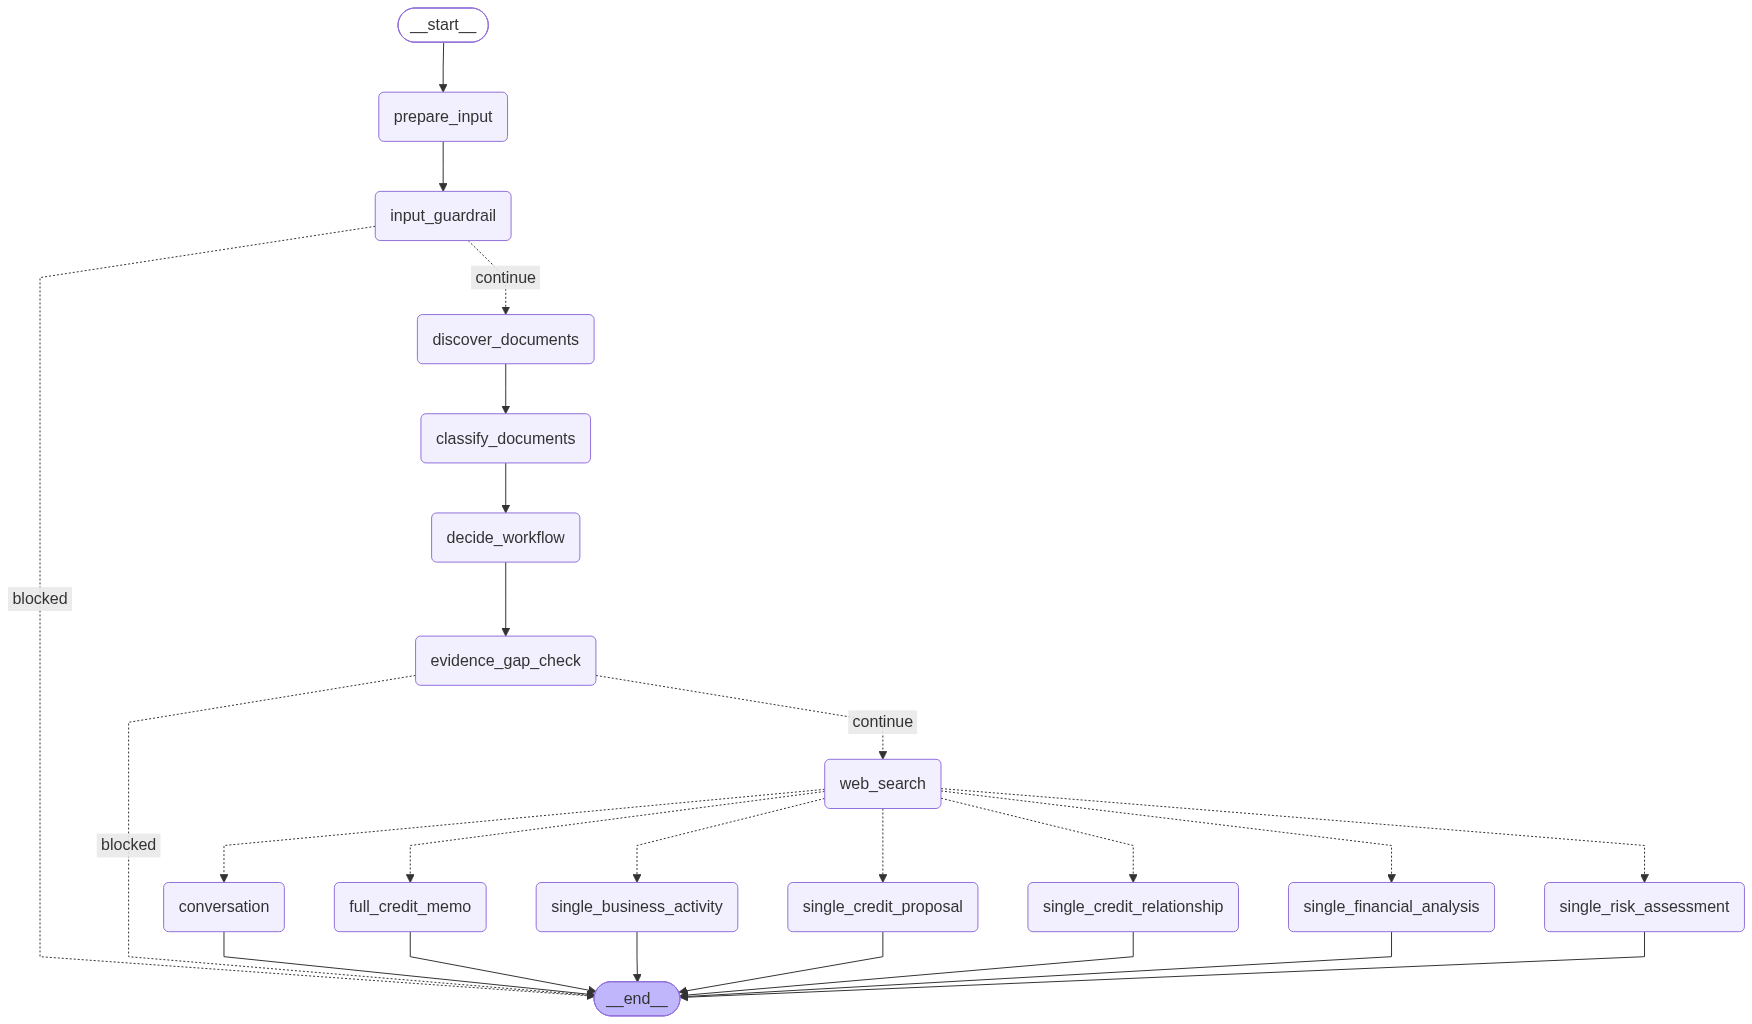

BadRequestError: Error code: 400 - {'error': {'message': 'you must provide a model parameter', 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [11]:
from src.utils.common import show_graph

supervisor = Supervisor(config)

display(Markdown("### Workflow Graph"))
display(show_graph(supervisor.workflow_graph))

workflow_runner = globals().get("run_supervisor_with_optional_trace")
if workflow_runner:
    result = workflow_runner(
        supervisor,
        QUERY,
        INPUT_PATHS,
        CONVERSATION_HISTORY,
    )
else:
    result = supervisor.process(QUERY, INPUT_PATHS, CONVERSATION_HISTORY)

display(Markdown(result["response"]))

print("\n--- Agent Name ---")
print(result["agent_name"])

print("\n--- Steps ---")
for step in result["steps"]:
    print("-", step)

print("\n--- Document Classifications ---")
classification_keys = [
    "filename",
    "agent",
    "confidence",
    "reasoning",
    "extraction_status",
    "extraction_error",
    "classifier_error_type",
    "classifier_error",
]
for item in result["document_classifications"]:
    classification = {key: item.get(key) for key in classification_keys}
    print(json.dumps(classification, ensure_ascii=False, indent=2))

## 12. Save Artifacts

In [ ]:
run_id = "_".join([TESTCASE_ID, datetime.now().strftime("%Y%m%d_%H%M%S")])
run_dir = OUTPUT_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

(run_dir / "final_response.md").write_text(
    result["response"],
    encoding="utf-8",
)
(run_dir / "result.json").write_text(
    json.dumps(result, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
(run_dir / "document_classifications.json").write_text(
    json.dumps(result["document_classifications"], ensure_ascii=False, indent=2),
    encoding="utf-8",
)
(run_dir / "agent_outputs.json").write_text(
    json.dumps(result["sub_agent_outputs"], ensure_ascii=False, indent=2),
    encoding="utf-8",
)
(run_dir / "hallucination_check.json").write_text(
    json.dumps(result["hallucination_check"], ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Saved artifacts to: {run_dir}")

Saved artifacts to: /Users/uspro/Works/1. AI/1. RADAR/1. SME_ReAct_chatbot/notebooks/logs/case_1_20260731_115202
